## Rasterio Workflow: STAC, COGs, NDVI, and Time Series 🛰️🌿📈

In this notebook, you'll work through a complete remote sensing workflow step by step. This is where you search for Sentinel-2 imagery with STAC, read raster subsets from cloud-hosted imagery, calculate NDVI, mask raster values by polygons, and build a simple NDVI time series.

### 🎯 What This Notebook Does
- Search Sentinel-2 imagery using a STAC catalog
- Inspect STAC items and scene assets
- Read raster windows from cloud-hosted imagery
- Calculate NDVI from red and NIR bands
- Mask NDVI by polygon features
- Build and visualize an NDVI time series

---

### ⚙️ Step 0: Select the Correct Python Kernel

Before running any cells, make sure the notebook is using the correct Python environment.

**Check the kernel in the top-right corner of the notebook.**

The correct Python environment is **python-gis-development (.venv)**  
It may appear with a Python version, for example:  
**python-gis-development (3.11.15) (Python 3.11.15) .venv/bin/python**



If the kernel is **python-gis-development (.venv)**, you can start running cells below.

Steps to select the correct kernel:
1. Click on the kernel (top right corner of the notebook) if it is not **python-gis-development (.venv)** or if it says "Select Kernel"
2. Select **python-gis-development (.venv)**
3. If you do not see the kernel in the list, click on "Select Another Kernel..."  
    a. Click on Python Environments...   
    b. Select **python-gis-development (.venv)**

Once the correct kernel is selected, you can start running cells below.

### 📚 Step 1: Import Libraries

Let's import the libraries needed for searching imagery, reading rasters, calculating NDVI, and working with polygon data.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
import geopandas as gpd
import rasterio
from rasterio import features
from rasterio.plot import show
from pyproj import Transformer
from pystac_client import Client
import planetary_computer
import matplotlib.dates as mdates
from datetime import datetime

stac_url = "https://planetarycomputer.microsoft.com/api/stac/v1"

print("✅ Libraries imported")
print(f"✅ STAC URL: {stac_url}")

✅ Libraries imported
✅ STAC URL: https://planetarycomputer.microsoft.com/api/stac/v1


### 🌍 Step 2: Define the Search Area and Date Range

We need a bounding box and a date range before searching for imagery.

In [2]:
# Bounding box: [west, south, east, north]
bbox = [-110.74772571639987, 32.270431012618026, -110.70996215904789, 32.29386169894274]

# Short date range for initial exploration
date_range = "2021-07-05/2021-08-02"

print(f"Bounding box: {bbox}")
print(f"Date range: {date_range}")

Bounding box: [-110.74772571639987, 32.270431012618026, -110.70996215904789, 32.29386169894274]
Date range: 2021-07-05/2021-08-02


### 🔎 Step 3: Build a Helper Function to Search STAC

In this step, you'll create a helper function to search for Sentinel-2 imagery using a STAC catalog.

💡 Helper functions make it easier to reuse code throughout the workflow, especially when the same steps are repeated multiple times.

In [3]:
def image_search(bbox, date_range, scene_cloud_tolerance):
    """
    Search for Sentinel-2 scenes using a STAC catalog.
    
    Args:
        bbox: [west, south, east, north]
        date_range: Date range in "YYYY-MM-DD/YYYY-MM-DD" format
        scene_cloud_tolerance: Maximum allowed cloud cover percentage
        
    Returns:
        List of matching STAC items
    """
    # Connect to the STAC API (metadata catalog, not imagery itself)
    catalog = Client.open(stac_url)
    
    # Build a search query using spatial, temporal, and metadata filters
    search = catalog.search(
        collections=["sentinel-2-l2a"],                         # Sentinel-2 Level-2A (surface reflectance)
        bbox=bbox,                                              # Spatial filter (area of interest)
        datetime=date_range,                                    # Temporal filter
        query={"eo:cloud_cover": {"lt": scene_cloud_tolerance}} # Metadata filter
    )
    
    # Convert search results into a list of STAC items (scenes)
    return list(search.items())

print("✅ Helper function created: image_search()")

✅ Helper function created: image_search()


### 🛰️ Step 4: Search for Imagery

Now let's use our helper function to find matching Sentinel-2 scenes.

In [4]:
items = image_search(bbox, date_range, 5)

print(f"✅ Found {len(items)} scenes")
for item in items:
    print(f"   - {item.id} on {item.datetime}")

✅ Found 3 scenes
   - S2A_MSIL2A_20210802T175921_R041_T12SWA_20210803T093522 on 2021-08-02 17:59:21.024000+00:00
   - S2B_MSIL2A_20210728T175909_R041_T12SWA_20210729T055315 on 2021-07-28 17:59:09.024000+00:00
   - S2B_MSIL2A_20210708T175909_R041_T12SWA_20210709T142932 on 2021-07-08 17:59:09.024000+00:00


### 🗂️ Step 5: Inspect One STAC Item and Its Assets

Each STAC item contains metadata and asset URLs for the scene.

In [6]:
item = items[0]

print(f"Item ID: {item.id}")
print(f"Datetime: {item.datetime}")
print(f"Bounding box: {item.bbox}")
print(f"Cloud cover: {item.properties.get('eo:cloud_cover', 'N/A')}%")
print()
print("Available assets:")
print(list(item.assets.keys()))
print()
print("Visual asset:")
print(item.assets['visual'])

Item ID: S2A_MSIL2A_20210802T175921_R041_T12SWA_20210803T093522
Datetime: 2021-08-02 17:59:21.024000+00:00
Bounding box: [-111.00021, 31.54153711388592, -109.83099, 32.53735523642313]
Cloud cover: 4.095239%

Available assets:
['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A', 'SCL', 'WVP', 'visual', 'preview', 'safe-manifest', 'granule-metadata', 'inspire-metadata', 'product-metadata', 'datastrip-metadata', 'tilejson', 'rendered_preview']

Visual asset:
<Asset href=https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/12/S/WA/2021/08/02/S2A_MSIL2A_20210802T175921_N0300_R041_T12SWA_20210803T093522.SAFE/GRANULE/L2A_T12SWA_A031927_20210802T181051/IMG_DATA/R10m/T12SWA_20210802T175921_TCI_10m.tif>


### 🪟 Step 6: Build a Helper Function for Windowed Reads

In this step, you'll create a helper function to read a subset of raster data from a cloud-hosted image using a bounding box.

💡 Instead of downloading an entire raster file, windowed reads allow you to load only the pixels you need. This is especially important when working with large satellite datasets stored in the cloud.

In [7]:
def windowed_read(url, bbox):
    """
    Read a raster subset from a cloud-hosted asset.
    
    Args:
        url: Raster asset URL
        bbox: [west, south, east, north]
        
    Returns:
        Tuple of (pixels, transform)
    """
    signed_url = planetary_computer.sign(url)
    
    with rasterio.open(signed_url) as src:
        # Convert bounding box from WGS84 (lat/lon) → raster CRS
        transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
        
        # Transform geographic coordinates into raster coordinate system
        left, bottom = transformer.transform(bbox[0], bbox[1])
        right, top = transformer.transform(bbox[2], bbox[3])
        
        # Convert spatial coordinates → pixel indices (row, col)
        row_start, col_start = src.index(left, top)
        row_stop, col_stop = src.index(right, bottom)
        
        # Define a window (subset of the raster)
        window = rasterio.windows.Window.from_slices(
            (row_start, row_stop),
            (col_start, col_stop)
        )
        
        # Read only the subset instead of the full image
        pixels = src.read(window=window)

        # Transform specific to this window (not full raster)
        transform = src.window_transform(window)
        
        return pixels, transform

print("✅ Helper function created: windowed_read()")

✅ Helper function created: windowed_read()


### 📥 Step 7: Read Red and NIR Raster Windows

Now let's read only the pixels inside our area of interest.

In [8]:
# Extract URLs for specific bands from the STAC item
red_url = item.assets["B04"].href       # Red band (Sentinel-2 band 4)
nir_url = item.assets["B08"].href       # Near Infrared band (Sentinel-2 band 8)
rgb_url = item.assets["visual"].href    # Pre-rendered RGB image

# Read only the subset of pixels within the bounding box
red_pixels, transform_window = windowed_read(red_url, bbox)
nir_pixels, _ = windowed_read(nir_url, bbox)

# Select the single band from the returned array
red_pixels = red_pixels[0]
nir_pixels = nir_pixels[0]

print(f"✅ Red shape: {red_pixels.shape}")
print(f"✅ NIR shape: {nir_pixels.shape}")
print(f"✅ Window transform: {transform_window}")

✅ Red shape: (261, 355)
✅ NIR shape: (261, 355)
✅ Window transform: | 10.00, 0.00, 523750.00|
| 0.00,-10.00, 3573050.00|
| 0.00, 0.00, 1.00|


### 🌿 Step 8: Calculate NDVI

NDVI is calculated as `(NIR - Red) / (NIR + Red)`.

In [9]:
# Convert to float to avoid integer division issues
ndvi = (nir_pixels.astype(float) - red_pixels.astype(float)) / (
    nir_pixels.astype(float) + red_pixels.astype(float)
)

print(f"✅ NDVI shape: {ndvi.shape}")
print(f"✅ NDVI min: {ndvi.min():.3f}")
print(f"✅ NDVI max: {ndvi.max():.3f}")
print(f"✅ NDVI mean: {ndvi.mean():.3f}")

✅ NDVI shape: (261, 355)
✅ NDVI min: -0.667
✅ NDVI max: 0.997
✅ NDVI mean: 0.258


### 🖼️ Step 9: Visualize RGB and NDVI

Let's compare the true-color imagery and the NDVI result.

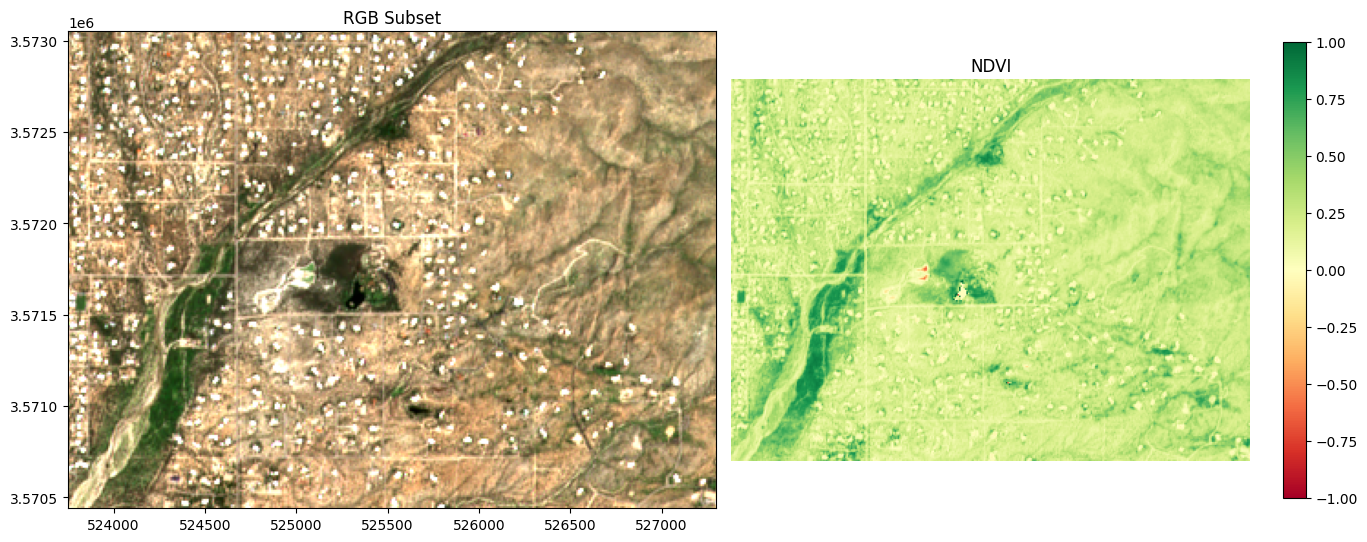

In [10]:
rgb_pixels, _ = windowed_read(rgb_url, bbox)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

show(rgb_pixels, transform=transform_window, ax=ax1)
ax1.set_title("RGB Subset")

im = ax2.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
ax2.set_title("NDVI")
ax2.axis("off")
plt.colorbar(im, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.show()

### 🧩 Step 10: Build a Helper Function to Mask NDVI by Polygon

In this step, you'll create a helper function to mask NDVI values using polygon geometries.

💡 Masking allows you to isolate raster values within specific areas (such as fields or neighborhoods) so you can analyze each region separately.

In [11]:
# Create a boolean mask where pixels OUTSIDE the polygon are True
def mask_ndvi_by_field(image, field_geom):
    """
    Mask NDVI values to a polygon.
    """
    mask = features.geometry_mask(
        [field_geom],                           # Geometry to mask with
        out_shape=image['ndvi'].shape,          # Must match NDVI array shape
        transform=image['transform_window'],    # Aligns raster to geometry
        all_touched=False,                      # Only include pixels fully inside
        invert=False                            # False = mask outside polygon
    )
    return ma.masked_array(image['ndvi'], mask)

print("✅ Helper function created: mask_ndvi_by_field()")

✅ Helper function created: mask_ndvi_by_field()


### 🗺️ Step 11: Load Polygon Data and Overlay on Imagery

Let's load polygon features and see where they fall on the raster imagery.

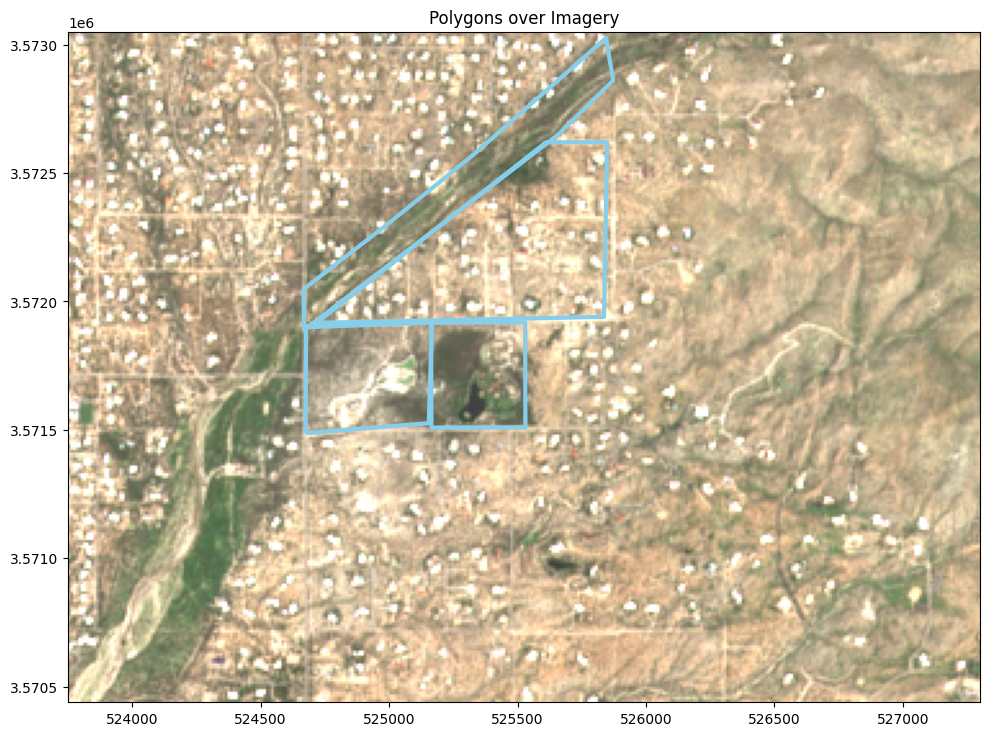

✅ Loaded 4 polygons


In [12]:
# Reproject polygons to match raster CRS (EPSG:32612)
fields = gpd.read_file('../../data/neighborhood_samples.geojson').to_crs(epsg=32612)

fig, ax = plt.subplots(1, figsize=(10, 10))
show(rgb_pixels, transform=transform_window, ax=ax, alpha=0.75)
fields.boundary.plot(ax=ax, color='skyblue', linewidth=3)
ax.set_title("Polygons over Imagery")
plt.tight_layout()
plt.show()

print(f"✅ Loaded {len(fields)} polygons")

### 🌿 Step 12: Mask NDVI Inside One Polygon

Let's test masking with one field first.

In [ ]:
image = {
    'date': item.datetime.strftime('%Y-%m-%d'), # Store scene date as a string
    'rgb': rgb_pixels,                          # RGB raster subset for visualization
    'ndvi': ndvi,                               # NDVI raster for analysis
    'transform_window': transform_window        # Spatial transform for this raster window
}

# Mask NDVI values using the first polygon
masked_ndvi = mask_ndvi_by_field(image, fields.iloc[0].geometry)

fig, ax = plt.subplots(figsize=(10, 10))

# Show RGB imagery as a background layer
show(image['rgb'], transform=image['transform_window'], ax=ax, alpha=0.5)

# Overlay masked NDVI values for the selected polygon
show(masked_ndvi, transform=image['transform_window'], ax=ax, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_title(f"Masked NDVI ({image['date']})")
plt.tight_layout()
plt.show()

print(f"✅ Mean NDVI inside polygon: {masked_ndvi.mean():.3f}")

### 🔁 Step 13: Build a Scene Collection for a Longer Time Series

Now let's repeat the workflow across a longer date range so we can analyze change through time.

In [ ]:
long_date_range = "2020-01-01/2021-12-31"
long_items = image_search(bbox, long_date_range, 5)
total = len(long_items)
print(f"🔎 {len(long_items)} scenes found for {long_date_range}")

# Store processed outputs for each scene
images = []

# Loop through each STAC item and build a consistent image dictionary
for i, item in enumerate(long_items, start=1):
    print(f"\rProcessing scene {i}/{total} ({item.datetime.date()})...", end="", flush=True)
    
    # Access band assets from the STAC item
    red_url = item.assets["B04"].href
    nir_url = item.assets["B08"].href
    visual_url = item.assets["visual"].href
    
    # Read raster subsets for analysis
    red_pixels, transform = windowed_read(red_url, bbox)
    nir_pixels, _ = windowed_read(nir_url, bbox)
    
    # Extract the single band from each raster
    red_pixels = red_pixels[0]
    nir_pixels = nir_pixels[0]

    # Compute NDVI for this scene
    ndvi = (nir_pixels.astype(float) - red_pixels.astype(float)) / (
        nir_pixels.astype(float) + red_pixels.astype(float)
    )
        
    # Read RGB subset for visualization
    rgb, _ = windowed_read(visual_url, bbox)

    # Select the 3 RGB bands
    rgb = rgb[[0, 1, 2]]
    
    # Store all outputs together for later analysis (time series)
    images.append({
        'date': item.datetime.strftime('%Y-%m-%d'),
        'rgb': rgb,
        'ndvi': ndvi,
        'transform_window': transform
    })

print(f"\n✅ Built collection with {len(images)} scenes")

### 📊 Step 14: Build and Plot an NDVI Time Series

Let's calculate the mean NDVI inside each polygon through time and plot the results.

In [ ]:
# Compute masked NDVI for each polygon in every image
for image in images:
    ndvi_fields = {}
    for index, row in fields.iterrows():
        # Store masked NDVI arrays for each polygon (keyed by area)
        ndvi_fields[row.area] = mask_ndvi_by_field(image, row.geometry)
    image['ndvi_fields'] = ndvi_fields

time_series_data = {}

# Build time series for each field across all images
for field_id in fields['area']:
    dates = []
    ndvi_values = []
    
    for image in images:
        dates.append(image['date'])
        # Use mean NDVI inside the polygon for this date
        ndvi_values.append(image['ndvi_fields'][field_id].mean())
    
    # Store results for plotting (including datetime conversion)
    time_series_data[field_id] = {
        'dates': dates,
        'ndvi': ndvi_values,
        'dates_dt': [datetime.strptime(d, '%Y-%m-%d') for d in dates]
    }

fig, ax = plt.subplots(figsize=(14, 8))

# Plot NDVI time series for each polygon
for field_id, data in time_series_data.items():
    ax.plot(
        data['dates_dt'],
        data['ndvi'],
        marker='o',
        linewidth=2,
        markersize=4,
        label=field_id
    )

ax.set_xlabel('Date')
ax.set_ylabel('Mean NDVI')
ax.set_title('NDVI Time Series by Field', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Format x-axis for readability
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 🔑 Key Learning Points

- **STAC** helps discover satellite imagery using metadata and scene assets
- **Cloud-Optimized GeoTIFFs (COGs)** allow efficient windowed raster reads
- **Raster transforms** connect pixel coordinates to geographic space
- **NDVI** is calculated from red and near-infrared bands
- **Raster masks** isolate values inside vector polygons
- A simple **time series** can summarize vegetation change through time
- Helper functions are useful when a workflow repeats the same steps